Baza oxford
Number of cat classes: 12
Number of dog classes: 25

imagenet labels:

74 dla psów

9 dla kotów

tabby

tiger cat

Persian cat

Siamese cat

Egyptian cat

leopard

snow leopard

jaguar

lion

tiger

cougar

Wspólne nazwy ras psów (z ImageNet i Oxford-IIIT Pet):

* Chihuahua
* Pug
* Boxer
* English setter
* Yorkshire terrier
* Beagle


6 wspólnych nazw ras dla psów.

Dla kotów nie ma wspólnych nazw

Zrobić predykcję dla kotów - dla pozostałych modeli
zrobić predykcje dla psów - dla wszystkich modeli
wybrać zdjęcia, które mają od 60% predykcji poprawnej klasy. (wszystko zależy od tego jakie będą wyniki i ile zdjęć zostanie)

Baza danych jest stworzona na podstawie kotów - 1188 zdjęć, 12 klas.
Dla każdego z 7 modelów - ['mobilenet_v3_large', 'efficientnet_b0', 'efficientnet_b3', 'squeezenet', 'resnet18', 'resnet50', 'vgg16'] zostały obliczone top-5 predykcji dla wybranych klas
/content/drive/MyDrive/XAI_Project/results/top5_all_predictions/ https://drive.google.com/drive/folders/1XkoPCAyAhj7xGS9m4izKwWQ8tRdOIs2n?usp=sharing

Wyniki każdego modelu zostały przefiltrowane dla top-1 to klasa kocia, a ich prawdopodobieństwo jest min. 0.3
/content/drive/MyDrive/XAI_Project/results/filtered cats/

Wszystkie pliki zostały porównanie i wybrano tylko te pliki, które są pojawiają się dla wszystkich modeli.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# model list
BASE_PATH = '/content/drive/MyDrive/XAI_Project'
MODELS_LIST = ['mobilenet_v3_large', 'efficientnet_b0', 'efficientnet_b3', 'squeezenet', 'resnet18']

# foldery dla każdego modelu
for model_name in MODELS_LIST:
    model_folder = os.path.join(BASE_PATH, 'results', model_name)
    os.makedirs(model_folder, exist_ok=True)

#print("Struktura folderów została przygotowana!")

In [ ]:
#ttach Dodatek pomagający w tzw. Test Time Augmentation, który bywa używany przy zaawansowanych wizualizacjach.
!pip install grad-cam lime ttach

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=43fc61b46b2d2f7151b4c071ff269203de1dbecf320bbd24223d66621f30556c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f13414b817424efc2aba5d531d494a57a16872ca78b5ec2e2de9a0d266c68adb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built grad-cam lime


In [ ]:
from tqdm import tqdm
from PIL import Image
import torchvision
import numpy as np
import cv2
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from PIL import Image

# 1. Pobieramy bazę (obrazy i maski)
dataset = torchvision.datasets.OxfordIIITPet(
    root='/content/drive/MyDrive/XAI_Project/data',
    split='trainval',
    target_types=('category', 'segmentation'),
    download=True
)

# 2. Wyciągamy listę ras i ich indeksy
all_classes = dataset.classes
cat_breeds = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
    'Egyptian Mau', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese',
    'Sphynx', 'Maine Coon'
]

# Znajdujemy indeksy dla kotów
cat_indices = [all_classes.index(breed) for breed in cat_breeds]
print(f"Indeksy naszych kotów: {cat_indices}")

# 1. Przygotowanie ścieżek i obrazów
image_dir = '/content/drive/MyDrive/XAI_Project/cats_images'
output_dir = '/content/drive/MyDrive/XAI_Project/results/resnet18'
os.makedirs(output_dir, exist_ok=True)

# Pobieramy 20 przykładowych ścieżek do zdjęć kotów
all_cat_files = []
for breed in os.listdir(image_dir):
    breed_path = os.path.join(image_dir, breed)
    if os.path.isdir(breed_path):
        files = [os.path.join(breed_path, f) for f in os.listdir(breed_path)]
        all_cat_files.extend(files)

selected_files = all_cat_files[:20]


Indeksy naszych kotów: [0, 5, 6, 7, 9, 11, 23, 26, 27, 32, 33, 20]


In [ ]:
print(f"Liczba wszystkich zdjęć w zbiorze danych: {len(dataset)}")
print(f"Liczba zdjęć kotów: {len(selected_files)}")


Liczba wszystkich zdjęć w zbiorze danych: 3680
Liczba zdjęć kotów: 20


In [ ]:
print(f"Liczba wszystkich zdjęć kotów: {len(all_cat_files)}")

Liczba wszystkich zdjęć kotów: 1188


In [ ]:
import torch
import torchvision.models as models

def load_all_models(device):
    # Słownik na nasze modele
    models_dict = {}

    # 1. ResNet18
    #models_dict['resnet18'] = models.resnet18(weights='IMAGENET1K_V1').to(device)

    # 2. MobileNet V3 Large
    #models_dict['mobilenet_v3_large'] = models.mobilenet_v3_large(weights='IMAGENET1K_V1').to(device)

    # 3. EfficientNet B0
    #models_dict['efficientnet_b0'] = models.efficientnet_b0(weights='IMAGENET1K_V1').to(device)

    # 4. EfficientNet B3
    #models_dict['efficientnet_b3'] = models.efficientnet_b3(weights='IMAGENET1K_V1').to(device)

    # 5. SqueezeNet 1.1
    models_dict['squeezenet'] = models.squeezenet1_1(weights='IMAGENET1K_V1').to(device)

    # 6. ResNet50
    models_dict['resnet50'] = models.resnet50(weights='IMAGENET1K_V1').to(device)

    # 7. VGG16
    #models_dict['vgg16'] = models.vgg16(weights='IMAGENET1K_V1').to(device)

    return models_dict

# Inicjalizacja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_models = load_all_models(device)
print(f"Załadowano {len(my_models)} modeli  ")

Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 12.1MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 30.6MB/s]


Załadowano 2 modeli  


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
resnet50_model = my_models['resnet50']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

In [ ]:
print(imagenet_classes)

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 

In [ ]:
# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu resnet50...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = resnet18_model(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'resnet50_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [09:35<00:00,  2.07it/s]


Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/resnet18_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,tiger cat,0.3432,tabby,0.2185,Egyptian cat,0.0728,plastic bag,0.0695,Persian cat,0.0262
1,cat_2.jpg,Egyptian cat,0.7149,tabby,0.1372,tiger cat,0.0765,lynx,0.0433,cougar,0.0077
2,cat_5.jpg,plastic bag,0.3493,Egyptian cat,0.2102,tabby,0.1093,sleeping bag,0.0865,lynx,0.0764
3,cat_1.jpg,Egyptian cat,0.4983,tabby,0.3002,tiger cat,0.1057,lynx,0.0610,kit fox,0.0100
4,cat_4.jpg,black-footed ferret,0.4701,weasel,0.2341,polecat,0.1294,Chihuahua,0.0412,kit fox,0.0398


MODELS_LIST = ['mobilenet_v3_large', 'efficientnet_b0', 'efficientnet_b3', 'squeezenet', 'resnet18', 'resnet50', 'vgg16']

In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
squeezenet = my_models['squeezenet']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu squeezenet...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = mobilenet_v3_large(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'squeezenet_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [00:47<00:00, 24.91it/s]


Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/mobilenet_v3_large_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,tiger cat,0.6667,Egyptian cat,0.1095,plastic bag,0.0499,quilt,0.0355,tabby,0.0303
1,cat_2.jpg,Egyptian cat,0.9254,tabby,0.0442,tiger cat,0.0204,lynx,0.0096,Persian cat,0.0001
2,cat_5.jpg,lynx,0.8284,Egyptian cat,0.1054,sleeping bag,0.0203,grey fox,0.0165,tabby,0.0144
3,cat_1.jpg,Egyptian cat,0.8925,tabby,0.0667,tiger cat,0.0243,Chihuahua,0.0074,Siamese cat,0.0039
4,cat_4.jpg,Egyptian cat,0.5303,Siamese cat,0.1266,tabby,0.1024,quilt,0.0688,polecat,0.0320


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
efficientnet_b0 = my_models['efficientnet_b0']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu ResNet18...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = efficientnet_b0(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'efficientnet_b0_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [01:26<00:00, 13.75it/s]



Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/efficientnet_b0_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,Egyptian cat,0.2642,tiger cat,0.2054,tabby,0.1389,plastic bag,0.1272,quilt,0.0310
1,cat_2.jpg,Egyptian cat,0.8216,tabby,0.0696,tiger cat,0.0291,lynx,0.0285,cougar,0.0022
2,cat_5.jpg,Egyptian cat,0.4613,sleeping bag,0.3060,plastic bag,0.0641,lynx,0.0444,tiger cat,0.0309
3,cat_1.jpg,Egyptian cat,0.6407,tabby,0.2099,tiger cat,0.0757,lynx,0.0027,Siamese cat,0.0017
4,cat_4.jpg,Siamese cat,0.2156,Egyptian cat,0.1338,black-footed ferret,0.0631,polecat,0.0529,Chihuahua,0.0337


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
efficientnet_b3 = my_models['efficientnet_b3']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu ResNet18...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = efficientnet_b3(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'efficientnet_b3_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [02:51<00:00,  6.94it/s]


Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/efficientnet_b3_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,tabby,0.1270,tiger cat,0.1057,plastic bag,0.1001,sleeping bag,0.0916,Egyptian cat,0.0852
1,cat_2.jpg,Egyptian cat,0.8417,tabby,0.0826,tiger cat,0.0304,lynx,0.0071,cougar,0.0012
2,cat_5.jpg,sleeping bag,0.3347,lynx,0.1260,Egyptian cat,0.1159,plastic bag,0.0650,tabby,0.0276
3,cat_1.jpg,Egyptian cat,0.7501,tabby,0.1393,tiger cat,0.0643,lynx,0.0103,cougar,0.0012
4,cat_4.jpg,Egyptian cat,0.5574,tabby,0.1453,black-footed ferret,0.0269,tiger cat,0.0252,polecat,0.0209


In [ ]:

import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
squeezenet = my_models['squeezenet']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu ResNet18...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = squeezenet(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'squeezenet_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [01:07<00:00, 17.67it/s]


Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/squeezenet_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,plastic bag,0.3134,Chihuahua,0.1549,Persian cat,0.1172,tabby,0.0894,Egyptian cat,0.0491
1,cat_2.jpg,Egyptian cat,0.6814,tabby,0.1730,tiger cat,0.1368,lynx,0.0085,plastic bag,0.0001
2,cat_5.jpg,Egyptian cat,0.3587,tiger cat,0.2560,tabby,0.1729,lynx,0.0910,plastic bag,0.0756
3,cat_1.jpg,Egyptian cat,0.4788,tabby,0.3352,tiger cat,0.1269,red fox,0.0167,carton,0.0041
4,cat_4.jpg,Egyptian cat,0.4449,Chihuahua,0.2983,tabby,0.0543,Pembroke,0.0390,black-footed ferret,0.0303


In [ ]:
import torch
import torchvision.models as models

def load_all_models(device):
    # Słownik na nasze modele
    models_dict = {}

    # 1. ResNet18
    models_dict['resnet50'] = models.resnet50(weights='IMAGENET1K_V1').to(device)

    # 2. MobileNet V3 Large
    models_dict['vgg16'] = models.vgg16(weights='IMAGENET1K_V1').to(device)

    # Przełączamy wszystkie modele w tryb ewaluacji (wyłączamy naukę)
    for name in models_dict:
        models_dict[name].eval()

    return models_dict

# Inicjalizacja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_models = load_all_models(device)
print(f"Załadowano {len(my_models)} modeli  ")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 73.8MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 62.4MB/s]


Załadowano 2 modeli  


In [ ]:

import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
resnet50 = my_models['resnet50']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu ResNet50...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = resnet50(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'resnet50_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [04:18<00:00,  4.60it/s]



Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/resnet50_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,sleeping bag,0.3212,Egyptian cat,0.1834,tiger cat,0.1435,tabby,0.1265,quilt,0.0290
1,cat_2.jpg,Egyptian cat,0.8714,tabby,0.0820,tiger cat,0.0301,lynx,0.0137,cougar,0.0008
2,cat_5.jpg,Egyptian cat,0.7309,sleeping bag,0.0917,plastic bag,0.0751,tabby,0.0620,tiger cat,0.0252
3,cat_1.jpg,tabby,0.4770,Egyptian cat,0.3473,tiger cat,0.1690,plastic bag,0.0014,Siamese cat,0.0007
4,cat_4.jpg,sleeping bag,0.2123,Egyptian cat,0.2046,tabby,0.1072,black-footed ferret,0.0336,Pembroke,0.0301


In [ ]:

import pandas as pd
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
import urllib

# 1. Definiujemy transformacje dla obrazów
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Pobieramy model resnet18
vgg16 = my_models['vgg16']

# 3. Ładujemy etykiety klas ImageNet
# Zazwyczaj pobierane z pliku lub URL, aby odwzorować indeksy na nazwy klas.
# Używamy prostego sposobu z pobieraniem z URL.
try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    with urllib.request.urlopen(url) as response:
        imagenet_classes = [line.strip() for line in response.read().decode().splitlines()]
except Exception as e:
    print(f"Błąd podczas pobierania etykiet ImageNet: {e}")
    print("Używam etykiet zastępczych. Sprawdź połączenie z internetem lub pobierz plik ręcznie.")
    imagenet_classes = [f"class_{i}" for i in range(1000)] # Etykiety zastępcze

results = []

# 4. Przechodzimy przez WSZYSTKIE zdjęcia i dokonujemy klasyfikacji
print(f"Rozpoczynam klasyfikację {len(all_cat_files)} zdjęć za pomocą modelu ResNet18...")
for image_path in tqdm(all_cat_files, desc="Klasyfikacja obrazów"):
    try:
        # Wczytujemy i przygotowujemy obraz
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img)
        img_tensor = img_tensor.unsqueeze(0).to(device) # Dodajemy wymiar partii i przenosimy na urządzenie

        with torch.no_grad(): # Wyłączamy obliczanie gradientów dla wnioskowania
            outputs = vgg16(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Obliczamy prawdopodobieństwa

            # Pobieramy top 5 prawdopodobieństw i ich indeksy
            top5_prob, top5_indices = torch.topk(probabilities, 5)

            image_results = {
                'filename': os.path.basename(image_path)
            }
            for i in range(5):
                class_idx = top5_indices[0][i].item()
                class_name = imagenet_classes[class_idx] if class_idx < len(imagenet_classes) else f"unknown_class_{class_idx}"
                probability = top5_prob[0][i].item()
                image_results[f'top_{i+1}_class'] = class_name
                image_results[f'top_{i+1}_probability'] = f'{probability:.4f}' # Formatujemy do 4 miejsc po przecinku
            results.append(image_results)

    except Exception as e:
        print(f"\nBłąd podczas przetwarzania obrazu {image_path}: {e}")
        results.append({'filename': os.path.basename(image_path), 'error': str(e)}) # Zapisujemy błędy

# 5. Tworzymy DataFrame i zapisujemy do pliku CSV
results_df = pd.DataFrame(results)
output_csv_path = os.path.join(output_dir, 'vgg16_top5_all_predictions.csv') # \ nazwa pliku
results_df.to_csv(output_csv_path, index=False)

print(f"\nKlasyfikacja zakończona! Wyniki zostały zapisane do pliku: {output_csv_path}")
print("Oto pierwsze kilka wierszy z wynikami:")
display(results_df.head())

Rozpoczynam klasyfikację 1188 zdjęć za pomocą modelu ResNet18...


Klasyfikacja obrazów: 100%|██████████| 1188/1188 [12:34<00:00,  1.58it/s]


Klasyfikacja zakończona! Wyniki zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/resnet18/vgg16_top5_all_predictions.csv
Oto pierwsze kilka wierszy z wynikami:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,sleeping bag,0.1854,tiger cat,0.1228,plastic bag,0.1209,tabby,0.0885,Egyptian cat,0.0815
1,cat_2.jpg,Egyptian cat,0.5943,tabby,0.2654,tiger cat,0.1320,carton,0.0019,lynx,0.0014
2,cat_5.jpg,Egyptian cat,0.5164,tabby,0.1258,tiger cat,0.1231,plastic bag,0.0895,sleeping bag,0.0577
3,cat_1.jpg,tabby,0.4383,Egyptian cat,0.3228,tiger cat,0.1950,Siamese cat,0.0090,feather boa,0.0046
4,cat_4.jpg,black-footed ferret,0.4925,polecat,0.2028,weasel,0.0757,Chihuahua,0.0716,Siamese cat,0.0212


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_index = 63 # Zmieniono indeks zdjęcia na 30
image_path = all_cat_files[image_index]
print(f"Wyświetlam zdjęcie: {os.path.basename(image_path)}")
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off') # Usuwamy osie dla lepszej widoczności zdjęcia

output_dir = '/content/drive/MyDrive/XAI_Project/results/resnet18'
output_csv_path = os.path.join(output_dir, 'resnet18_top5_all_predictions.csv')
results_df = pd.read_csv(output_csv_path)

selected_image_filename = os.path.basename(all_cat_files[image_index])
image_predictions = results_df[results_df['filename'] == selected_image_filename]
display(image_predictions) # Wyświetlamy predykcje dla nowego zdjęcia

NameError: name 'all_cat_files' is not defined

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import pandas as pd

# --- Zmiana: Podaj nazwę pliku, który chcesz wyświetlić ---
target_filename = 'cat_1662.jpg' # Zmień tę nazwę na inną, aby wyświetlić inne zdjęcie

# Znajdź pełną ścieżkę do obrazu na podstawie nazwy pliku
image_path = None
for path in all_cat_files:
    if os.path.basename(path) == target_filename:
        image_path = path
        break

if image_path:
    print(f"Wyświetlam zdjęcie: {os.path.basename(image_path)}")
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off') # Usuwamy osie dla lepszej widoczności zdjęcia
    plt.show() # Pokaż wykres

    output_dir = '/content/drive/MyDrive/XAI_Project/results/resnet18'
    output_csv_path = os.path.join(output_dir, 'resnet18_top5_all_predictions.csv')
    results_df = pd.read_csv(output_csv_path)

    # Pobierz predykcje dla wybranego pliku
    image_predictions = results_df[results_df['filename'] == target_filename]

    if not image_predictions.empty:
        print(f"Predykcje dla pliku '{target_filename}':")
        display(image_predictions) # Wyświetlamy predykcje jako tabelę
    else:
        print(f"Brak predykcji dla pliku '{target_filename}' w pliku CSV.")
else:
    print(f"Błąd: Plik '{target_filename}' nie został znaleziony w folderze ze zdjęciami kotów.")

NameError: name 'all_cat_files' is not defined

In [ ]:
dog_keywords = [
    'dog', 'hound', 'terrier', 'spaniel', 'retriever', 'shepherd', 'poodle',
    'dachshund', 'bulldog', 'collie', 'boxer', 'rottweiler', 'doberman',
    'chihuahua', 'greyhound', 'husky', 'maltese', 'pug', 'shih tzu', 'siberian',
    'schnauzer', 'beagle', 'basset', 'setter', 'labrador', 'german',
    'golden', 'dalmatian', 'pit bull'
]

dog_labels_count = 0
dog_labels = []

print("Rozpoczynam wyszukiwanie etykiet związanych z psami...")

for label in imagenet_classes:
    # Normalizujemy etykietę do małych liter dla lepszego dopasowania
    lower_label = label.lower()

    # Sprawdzamy, czy etykieta zawiera którekolwiek ze słów kluczowych
    if any(keyword in lower_label for keyword in dog_keywords):
        dog_labels_count += 1
        dog_labels.append(label)

print(f"\nZnaleziono {dog_labels_count} etykiet związanych z psami lub ich rasami w pliku imagenet_classes.txt.")
print("Oto niektóre z nich:")
for i, label in enumerate(dog_labels[:20]): # Wyświetlamy pierwsze 20 dla przykładu
    print(f"- {label}")
if len(dog_labels) > 20:
    print(f"... i wiele więcej (łącznie {len(dog_labels)}).")

Rozpoczynam wyszukiwanie etykiet związanych z psami...

Znaleziono 74 etykiet związanych z psami lub ich rasami w pliku imagenet_classes.txt.
Oto niektóre z nich:
- Chihuahua
- Japanese spaniel
- Maltese dog
- Blenheim spaniel
- toy terrier
- Afghan hound
- basset
- beagle
- bloodhound
- black-and-tan coonhound
- Walker hound
- English foxhound
- Irish wolfhound
- Italian greyhound
- Ibizan hound
- Norwegian elkhound
- otterhound
- Scottish deerhound
- Staffordshire bullterrier
- American Staffordshire terrier
... i wiele więcej (łącznie 74).


In [ ]:
cat_keywords = [
    'cat', 'tabby', 'persian', 'siamese', 'egyptian', 'maine coon', 'ragdoll',
    'abyssinian', 'bengal', 'birman', 'bombay', 'british shorthair', 'sphynx',
    'russian blue', 'tiger cat'
]

cat_labels_count = 0
cat_labels = []

print("Rozpoczynam wyszukiwanie etykiet związanych z kotami...")

for label in imagenet_classes:
    lower_label = label.lower()
    if any(keyword in lower_label for keyword in cat_keywords):
        cat_labels_count += 1
        cat_labels.append(label)

print(f"\nZnaleziono {cat_labels_count} etykiet związanych z kotami lub ich rasami w pliku imagenet_classes.txt.")
print("Oto niektóre z nich:")
for i, label in enumerate(cat_labels[:20]): # Wyświetlamy pierwsze 20 dla przykładu
    print(f"- {label}")
if len(cat_labels) > 20:
    print(f"... i wiele więcej (łącznie {len(cat_labels)}).")

Rozpoczynam wyszukiwanie etykiet związanych z kotami...


NameError: name 'imagenet_classes' is not defined

In [ ]:
import os

output_labels_dir = os.path.join(BASE_PATH, 'results')
os.makedirs(output_labels_dir, exist_ok=True)

# Zapisujemy etykiety psów do pliku tekstowego
dog_labels_filepath = os.path.join(output_labels_dir, 'dog_labels.txt')
with open(dog_labels_filepath, 'w') as f:
    for label in dog_labels:
        f.write(label + '\n')
print(f"Etykiety psów zostały zapisane do pliku: {dog_labels_filepath}")

# Zapisujemy etykiety kotów do pliku tekstowego
cat_labels_filepath = os.path.join(output_labels_dir, 'cat_labels.txt')
with open(cat_labels_filepath, 'w') as f:
    for label in cat_labels:
        f.write(label + '\n')
print(f"Etykiety kotów zostały zapisane do pliku: {cat_labels_filepath}")

Etykiety psów zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/dog_labels.txt
Etykiety kotów zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/cat_labels.txt


In [ ]:
# 1. Wyodrębniamy rasy psów z listy wszystkich klas datasetu
# Zakładamy, że all_classes i cat_breeds są już dostępne z poprzednich komórek
# all_classes zawiera zarówno rasy kotów, jak i psów
# cat_breeds zawiera listę ras kotów z datasetu

dataset_dog_breeds = []
for breed in all_classes:
    if breed not in cat_breeds:
        dataset_dog_breeds.append(breed)

print(f"Rasy psów w datasetcie Oxford-IIIT Pet ({len(dataset_dog_breeds)}):")
print(dataset_dog_breeds[:10]) # Wyświetlamy pierwsze 10 dla podglądu

# 2. Przygotowujemy listy do porównania (konwertujemy na małe litery i sety dla efektywności)
# dog_labels pochodzi z poprzedniej analizy etykiet ImageNet

dataset_dog_breeds_lower = set(b.lower() for b in dataset_dog_breeds)
imageNet_dog_labels_lower = set(l.lower() for l in dog_labels)

# 3. Znajdujemy wspólne etykiety
common_dog_labels = dataset_dog_breeds_lower.intersection(imageNet_dog_labels_lower)

print(f"\nLiczba wspólnych nazw ras psów między datasetem a etykietami ImageNet: {len(common_dog_labels)}")
print("Wspólne nazwy (pierwsze 10, jeśli jest ich więcej):")
for i, label in enumerate(list(common_dog_labels)[:10]):
    print(f"- {label.capitalize()}") # Wyświetlamy z dużej litery dla lepszej czytelności
if len(common_dog_labels) > 10:
    print("... i wiele więcej.")

Rasy psów w datasetcie Oxford-IIIT Pet (25):
['American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Boxer', 'Chihuahua', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees']

Liczba wspólnych nazw ras psów między datasetem a etykietami ImageNet: 6
Wspólne nazwy (pierwsze 10, jeśli jest ich więcej):
- Chihuahua
- Pug
- Boxer
- English setter
- Yorkshire terrier
- Beagle


In [ ]:
# 1. Rasy kotów z datasetu (już mamy w cat_breeds)
print(f"Rasy kotów w datasetcie Oxford-IIIT Pet ({len(cat_breeds)}):")
print(cat_breeds[:10]) # Wyświetlamy pierwsze 10 dla podglądu

# 2. Przygotowujemy listy do porównania (konwertujemy na małe litery i sety dla efektywności)
# cat_labels pochodzi z poprzedniej analizy etykiet ImageNet

dataset_cat_breeds_lower = set(b.lower() for b in cat_breeds)
imageNet_cat_labels_lower = set(l.lower() for l in cat_labels)

# 3. Znajdujemy wspólne etykiety
common_cat_labels = dataset_cat_breeds_lower.intersection(imageNet_cat_labels_lower)

print(f"\nLiczba wspólnych nazw ras kotów między datasetem a etykietami ImageNet: {len(common_cat_labels)}")
print("Wspólne nazwy (pierwsze 10, jeśli jest ich więcej):")
for i, label in enumerate(list(common_cat_labels)[:10]):
    print(f"- {label.capitalize()}") # Wyświetlamy z dużej litery dla lepszej czytelności
if len(common_cat_labels) > 10:
    print("... i wiele więcej.")

NameError: name 'cat_breeds' is not defined

In [ ]:
import torch
import torchvision.models as models

def load_all_models(device):
    # Słownik na nasze modele
    models_dict = {}

    # 1. ResNet18
    models_dict['resnet18'] = models.resnet18(weights='IMAGENET1K_V1').to(device)

    # 2. MobileNet V3 Large
    models_dict['mobilenet_v3_large'] = models.mobilenet_v3_large(weights='IMAGENET1K_V1').to(device)

    # 3. EfficientNet B0
    models_dict['efficientnet_b0'] = models.efficientnet_b0(weights='IMAGENET1K_V1').to(device)

    # 4. EfficientNet B3
    models_dict['efficientnet_b3'] = models.efficientnet_b3(weights='IMAGENET1K_V1').to(device)

    # 5. SqueezeNet 1.1
    models_dict['squeezenet'] = models.squeezenet1_1(weights='IMAGENET1K_V1').to(device)

    # Przełączamy wszystkie modele w tryb ewaluacji (wyłączamy naukę)
    for name in models_dict:
        models_dict[name].eval()

    return models_dict

# Inicjalizacja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_models = load_all_models(device)
print(f"Załadowano {len(my_models)} modeli  ")

Załadowano 5 modeli  


In [ ]:
target_cat_classes = [
    'tabby cat', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian Mau',
    'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cougar'
]
probability_threshold = 0.3

print(f"Target cat classes defined: {target_cat_classes}")
print(f"Probability threshold set to: {probability_threshold}")

Target cat classes defined: ['tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat', 'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cougar']
Probability threshold set to: 0.3


In [ ]:
import pandas as pd
import os

# Step 1: Load predictions
# Correcting the file_path based on previous execution output
file_path = '/content/drive/MyDrive/XAI_Project/results/top5_all_predictions/efficientnet_b0_top5_all_predictions.csv'
mobilenet_df = pd.read_csv(file_path)

print("efficientnet_b0_top5_all_predictions.csv loaded successfully into efficientnet_b0_df.")
print("First 5 rows of the DataFrame:")
display(mobilenet_df.head())

# Step 2: Define target classes and probability threshold
target_cat_classes = [
    'tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat',
    'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cougar'
]
probability_threshold = 0.3

# Step 3: Filter DataFrame
# Ensure 'top_1_probability' is numeric for comparison
mobilenet_df['top_1_probability'] = pd.to_numeric(mobilenet_df['top_1_probability'], errors='coerce')

filtered_df = mobilenet_df[
    (mobilenet_df['top_1_class'].isin(target_cat_classes)) &
    (mobilenet_df['top_1_probability'] >= probability_threshold)
]

print(f"\nFiltered DataFrame contains {len(filtered_df)} rows.")
print("First 5 rows of the filtered DataFrame:")
display(filtered_df.head())

# Step 4: Save filtered results
output_directory = '/content/drive/MyDrive/XAI_Project/results/filtered cats'
os.makedirs(output_directory, exist_ok=True) # Ensure the output directory exists

output_filename = 'efficientnet_b0_filtered_cats.csv'
output_path = os.path.join(output_directory, output_filename)

filtered_df.to_csv(output_path, index=False)

print(f"\nFiltered results saved to: {output_path}")

efficientnet_b0_top5_all_predictions.csv loaded successfully into efficientnet_b0_df.
First 5 rows of the DataFrame:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
0,cat_0.jpg,Egyptian cat,0.2642,tiger cat,0.2054,tabby,0.1389,plastic bag,0.1272,quilt,0.0310
1,cat_2.jpg,Egyptian cat,0.8216,tabby,0.0696,tiger cat,0.0291,lynx,0.0285,cougar,0.0022
2,cat_5.jpg,Egyptian cat,0.4613,sleeping bag,0.3060,plastic bag,0.0641,lynx,0.0444,tiger cat,0.0309
3,cat_1.jpg,Egyptian cat,0.6407,tabby,0.2099,tiger cat,0.0757,lynx,0.0027,Siamese cat,0.0017
4,cat_4.jpg,Siamese cat,0.2156,Egyptian cat,0.1338,black-footed ferret,0.0631,polecat,0.0529,Chihuahua,0.0337



Filtered DataFrame contains 955 rows.
First 5 rows of the filtered DataFrame:


,filename,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability,top_4_class,top_4_probability,top_5_class,top_5_probability
1,cat_2.jpg,Egyptian cat,0.8216,tabby,0.0696,tiger cat,0.0291,lynx,0.0285,cougar,0.0022
2,cat_5.jpg,Egyptian cat,0.4613,sleeping bag,0.3060,plastic bag,0.0641,lynx,0.0444,tiger cat,0.0309
3,cat_1.jpg,Egyptian cat,0.6407,tabby,0.2099,tiger cat,0.0757,lynx,0.0027,Siamese cat,0.0017
5,cat_3.jpg,Egyptian cat,0.6293,tabby,0.1165,tiger cat,0.0838,quilt,0.0127,lynx,0.0094
6,cat_7.jpg,Egyptian cat,0.4442,tabby,0.1836,tiger cat,0.1295,lynx,0.0236,bath towel,0.0048



Filtered results saved to: /content/drive/MyDrive/XAI_Project/results/filtered cats/efficientnet_b0_filtered_cats.csv


In [ ]:
import os

# Define the path to the directory containing the filtered CSV files
filtered_cats_dir = '/content/drive/MyDrive/XAI_Project/results/filtered cats/'

# Get a list of all files in this directory
all_files = os.listdir(filtered_cats_dir)

# Filter the list to include only files that end with '.csv' and store their full paths
filtered_csv_files = [os.path.join(filtered_cats_dir, f) for f in all_files if f.endswith('.csv')]

print(f"Found {len(filtered_csv_files)} CSV files in '{filtered_cats_dir}':")
for f in filtered_csv_files:
    print(f)

Found 7 CSV files in '/content/drive/MyDrive/XAI_Project/results/filtered cats/':
/content/drive/MyDrive/XAI_Project/results/filtered cats/mobilenet_v3_large_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/resnet18_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/vgg16_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/resnet50_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/squeezenet_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/efficientnet_b3_filtered_cats.csv
/content/drive/MyDrive/XAI_Project/results/filtered cats/efficientnet_b0_filtered_cats.csv


In [ ]:
import pandas as pd
import os

# Initialize an empty list to store processed DataFrames
all_processed_dfs = []

# Iterate through each CSV file path
for csv_file_path in filtered_csv_files:
    # a. Load the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)

    # b. Extract the model name from the csv_file_path
    filename = os.path.basename(csv_file_path)
    # Remove '_filtered_cats.csv' to get the model name
    model_name = filename.replace('_filtered_cats.csv', '')

    # c. Create a new DataFrame with 'filename', 'top_1_class', and 'top_1_probability'
    processed_df = df[['filename', 'top_1_class', 'top_1_probability']].copy()

    # d. Rename the columns to include the model name
    processed_df.rename(columns={
        'top_1_class': f'{model_name}_top_1_class',
        'top_1_probability': f'{model_name}_top_1_probability'
    }, inplace=True)

    # e. Append this renamed DataFrame to the list
    all_processed_dfs.append(processed_df)

print(f"Processed {len(all_processed_dfs)} DataFrames.")
print("First few rows of the first processed DataFrame:")
display(all_processed_dfs[0].head())

Processed 7 DataFrames.
First few rows of the first processed DataFrame:


,filename,mobilenet_v3_large_top_1_class,mobilenet_v3_large_top_1_probability
0,cat_0.jpg,tiger cat,0.6667
1,cat_2.jpg,Egyptian cat,0.9254
2,cat_1.jpg,Egyptian cat,0.8925
3,cat_4.jpg,Egyptian cat,0.5303
4,cat_3.jpg,Egyptian cat,0.4597


In [ ]:
import functools

# Merge all processed DataFrames into a single DataFrame
# Use functools.reduce with pd.merge to perform a series of outer joins
merged_df = functools.reduce(lambda left, right: pd.merge(left, right, on='filename', how='outer'), all_processed_dfs)

print("Merged DataFrame created successfully.")
print("First few rows of the merged DataFrame:")
display(merged_df.head())


Merged DataFrame created successfully.
First few rows of the merged DataFrame:


,filename,mobilenet_v3_large_top_1_class,mobilenet_v3_large_top_1_probability,resnet18_top_1_class,resnet18_top_1_probability,vgg16_top_1_class,vgg16_top_1_probability,resnet50_top_1_class,resnet50_top_1_probability,squeezenet_top_1_class,squeezenet_top_1_probability,efficientnet_b3_top_1_class,efficientnet_b3_top_1_probability,efficientnet_b0_top_1_class,efficientnet_b0_top_1_probability
0,cat_0.jpg,tiger cat,0.6667,tiger cat,0.3432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cat_1.jpg,Egyptian cat,0.8925,Egyptian cat,0.4983,tabby,0.4383,tabby,0.4770,Egyptian cat,0.4788,Egyptian cat,0.7501,Egyptian cat,0.6407
2,cat_10.jpg,Egyptian cat,0.8903,Egyptian cat,0.7733,Egyptian cat,0.5374,Egyptian cat,0.9525,Egyptian cat,0.7706,Egyptian cat,0.8437,Egyptian cat,0.9505
3,cat_1000.jpg,Persian cat,0.4616,Persian cat,0.4177,NaN,NaN,tiger cat,0.3745,tiger cat,0.5117,tiger cat,0.3151,Persian cat,0.6278
4,cat_1001.jpg,Persian cat,0.9481,Persian cat,0.6175,Persian cat,0.9698,Persian cat,0.8303,Persian cat,0.7748,tabby,0.3601,Persian cat,0.7441


In [ ]:
import os

# Define the output directory for combined results
output_directory = os.path.join('/content/drive/MyDrive/XAI_Project/results', 'combined_predictions')
os.makedirs(output_directory, exist_ok=True) # Ensure the output directory exists

# Define the output filename
output_filename = 'all_models_combined_cat_predictions.csv'
output_path = os.path.join(output_directory, output_filename)

# Save the merged DataFrame to a CSV file
merged_df.to_csv(output_path, index=False)

print(f"Combined results saved to: {output_path}")

Combined results saved to: /content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions.csv


In [ ]:
import pandas as pd
import os

file_path = '/content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions.csv'

try:
    combined_predictions_df = pd.read_csv(file_path)
    print(f"Plik '{os.path.basename(file_path)}' wczytany pomyślnie.")

    # Sprawdź, ile wierszy zawiera puste rekordy
    # `isna()` tworzy ramkę boolean, `any(axis=1)` sprawdza, czy w danym wierszu jest True (czyli NA)
    # `sum()` zlicza True, co daje liczbę wierszy z brakującymi danymi
    rows_with_na = combined_predictions_df.isna().any(axis=1).sum()

    print(f"\nLiczba wierszy zawierających puste rekordy: {rows_with_na}")

    # Opcjonalnie: Wyświetl pierwsze kilka wierszy, aby zobaczyć wczytane dane
    print("\nPierwsze 5 wierszy wczytanego DataFrame:")
    display(combined_predictions_df.head())

except FileNotFoundError:
    print(f"Błąd: Plik '{file_path}' nie został znaleziony. Sprawdź poprawność ścieżki.")
except Exception as e:
    print(f"Wystąpił błąd podczas wczytywania pliku lub analizy: {e}")

Plik 'all_models_combined_cat_predictions.csv' wczytany pomyślnie.

Liczba wierszy zawierających puste rekordy: 532

Pierwsze 5 wierszy wczytanego DataFrame:


,filename,mobilenet_v3_large_top_1_class,mobilenet_v3_large_top_1_probability,resnet18_top_1_class,resnet18_top_1_probability,vgg16_top_1_class,vgg16_top_1_probability,resnet50_top_1_class,resnet50_top_1_probability,squeezenet_top_1_class,squeezenet_top_1_probability,efficientnet_b3_top_1_class,efficientnet_b3_top_1_probability,efficientnet_b0_top_1_class,efficientnet_b0_top_1_probability
0,cat_0.jpg,tiger cat,0.6667,tiger cat,0.3432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cat_1.jpg,Egyptian cat,0.8925,Egyptian cat,0.4983,tabby,0.4383,tabby,0.4770,Egyptian cat,0.4788,Egyptian cat,0.7501,Egyptian cat,0.6407
2,cat_10.jpg,Egyptian cat,0.8903,Egyptian cat,0.7733,Egyptian cat,0.5374,Egyptian cat,0.9525,Egyptian cat,0.7706,Egyptian cat,0.8437,Egyptian cat,0.9505
3,cat_1000.jpg,Persian cat,0.4616,Persian cat,0.4177,NaN,NaN,tiger cat,0.3745,tiger cat,0.5117,tiger cat,0.3151,Persian cat,0.6278
4,cat_1001.jpg,Persian cat,0.9481,Persian cat,0.6175,Persian cat,0.9698,Persian cat,0.8303,Persian cat,0.7748,tabby,0.3601,Persian cat,0.7441


In [ ]:
import os
import pandas as pd

# Upewniamy się, że DataFrame jest wczytany
# Jeśli combined_predictions_df nie jest już w pamięci, wczytujemy go z pliku CSV
if 'combined_predictions_df' not in locals() or combined_predictions_df.empty:
    file_path = '/content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions.csv'
    try:
        combined_predictions_df = pd.read_csv(file_path)
        print("Wczytano wyniki klasyfikacji z pliku CSV.")
    except FileNotFoundError:
        print("Błąd: Plik z połączonymi predykcjami nie został znaleziony.")
        combined_predictions_df = pd.DataFrame() # Tworzymy pusty DataFrame

if not combined_predictions_df.empty:
    # Filtrujemy wiersze, które NIE zawierają żadnych pustych rekordów (NaN)
    df_without_nan = combined_predictions_df.dropna()

    # Wyświetlamy liczbę wierszy bez pustych rekordów
    num_rows_without_nan = len(df_without_nan)
    print(f"\nLiczba wierszy bez pustych rekordów: {num_rows_without_nan}")

    # Zapisujemy nowy DataFrame do pliku CSV
    output_directory = '/content/drive/MyDrive/XAI_Project/results/combined_predictions'
    output_filename = 'all_models_combined_cat_predictions_without_nan.csv'
    output_path = os.path.join(output_directory, output_filename)

    df_without_nan.to_csv(output_path, index=False)

    print(f"\nWiersze bez pustych rekordów zostały zapisane do pliku: {output_path}")
    print("Oto pierwsze kilka wierszy z nowego pliku:")
    display(df_without_nan.head())
else:
    print("Brak danych do przetworzenia. DataFrame jest pusty.")


Liczba wierszy bez pustych rekordów: 598

Wiersze bez pustych rekordów zostały zapisane do pliku: /content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions_without_nan.csv
Oto pierwsze kilka wierszy z nowego pliku:


,filename,mobilenet_v3_large_top_1_class,mobilenet_v3_large_top_1_probability,resnet18_top_1_class,resnet18_top_1_probability,vgg16_top_1_class,vgg16_top_1_probability,resnet50_top_1_class,resnet50_top_1_probability,squeezenet_top_1_class,squeezenet_top_1_probability,efficientnet_b3_top_1_class,efficientnet_b3_top_1_probability,efficientnet_b0_top_1_class,efficientnet_b0_top_1_probability
1,cat_1.jpg,Egyptian cat,0.8925,Egyptian cat,0.4983,tabby,0.4383,tabby,0.4770,Egyptian cat,0.4788,Egyptian cat,0.7501,Egyptian cat,0.6407
2,cat_10.jpg,Egyptian cat,0.8903,Egyptian cat,0.7733,Egyptian cat,0.5374,Egyptian cat,0.9525,Egyptian cat,0.7706,Egyptian cat,0.8437,Egyptian cat,0.9505
4,cat_1001.jpg,Persian cat,0.9481,Persian cat,0.6175,Persian cat,0.9698,Persian cat,0.8303,Persian cat,0.7748,tabby,0.3601,Persian cat,0.7441
5,cat_1002.jpg,tabby,0.4907,tabby,0.5328,tabby,0.3836,tabby,0.5401,tabby,0.5268,tabby,0.4116,tiger cat,0.5184
7,cat_1004.jpg,tabby,0.8665,tabby,0.5675,tabby,0.7074,tabby,0.7319,tabby,0.8402,tabby,0.8195,tabby,0.7466


Plik 'all_models_combined_cat_predictions.csv' wczytany pomyślnie.
Wyświetlam zdjęcie: cat_1025.jpg


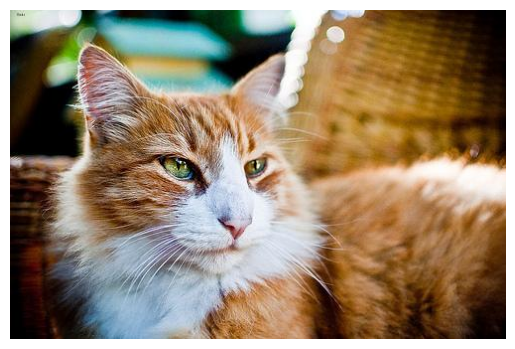


Predykcje dla pliku 'cat_1025.jpg' ze wszystkich modeli:


,filename,mobilenet_v3_large_top_1_class,mobilenet_v3_large_top_1_probability,resnet18_top_1_class,resnet18_top_1_probability,vgg16_top_1_class,vgg16_top_1_probability,resnet50_top_1_class,resnet50_top_1_probability,squeezenet_top_1_class,squeezenet_top_1_probability,efficientnet_b3_top_1_class,efficientnet_b3_top_1_probability,efficientnet_b0_top_1_class,efficientnet_b0_top_1_probability
28,cat_1025.jpg,tabby,0.5184,tiger cat,0.4596,tiger cat,0.825,tiger cat,0.3954,tiger cat,0.8682,tiger cat,0.6067,tiger cat,0.3439


In [ ]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# --- Re-initialize all_cat_files ---
image_dir = '/content/drive/MyDrive/XAI_Project/cats_images'
all_cat_files = []
if os.path.exists(image_dir):
    for breed in os.listdir(image_dir):
        breed_path = os.path.join(image_dir, breed)
        if os.path.isdir(breed_path):
            files = [os.path.join(breed_path, f) for f in os.listdir(breed_path)]
            all_cat_files.extend(files)

# --- Podaj nazwę pliku, który chcesz wyświetlić ---
target_filename = 'cat_1025.jpg' # Zmień tę nazwę na inną, aby wyświetlić inne zdjęcie

# Wczytujemy plik z połączonymi predykcjami
combined_predictions_file_path = '/content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions.csv'

try:
    combined_predictions_df = pd.read_csv(combined_predictions_file_path)
    print(f"Plik '{os.path.basename(combined_predictions_file_path)}' wczytany pomyślnie.")
except FileNotFoundError:
    print(f"Błąd: Plik '{combined_predictions_file_path}' nie został znaleziony. Upewnij się, że został wcześniej utworzony.")
    combined_predictions_df = pd.DataFrame() # Tworzymy pusty DataFrame, aby uniknąć błędów

# Znajdź pełną ścieżkę do obrazu na podstawie nazwy pliku
image_path = None
if all_cat_files:
    for path in all_cat_files:
        if os.path.basename(path) == target_filename:
            image_path = path
            break

if image_path and not combined_predictions_df.empty:
    print(f"Wyświetlam zdjęcie: {os.path.basename(image_path)}")
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off') # Usuwamy osie dla lepszej widoczności zdjęcia
    plt.show() # Pokaż wykres

    # Pobierz predykcje dla wybranego pliku z DataFrame
    image_predictions = combined_predictions_df[combined_predictions_df['filename'] == target_filename]

    if not image_predictions.empty:
        print(f"\nPredykcje dla pliku '{target_filename}' ze wszystkich modeli:")
        display(image_predictions) # Wyświetlamy predykcje jako tabelę
    else:
        print(f"Brak predykcji dla pliku '{target_filename}' w pliku combined_predictions.csv.")
elif not image_path:
    print(f"Błąd: Plik '{target_filename}' nie został znaleziony w folderze ze zdjęciami kotów.\n")
    print("Przykładowe dostępne nazwy plików:")
    if all_cat_files:
        for i, file in enumerate(all_cat_files[:10]):
            print(f"- {os.path.basename(file)}")
    else:
        print("Brak zdjęć kotów w folderze, aby wyświetlić przykładowe nazwy.")
else:
    print("Brak danych do przetworzenia. Upewnij się, że plik combined_predictions został wczytany.")

In [ ]:
import pandas as pd
import os

# 1. Załaduj plik 'all_models_combined_cat_predictions.csv'
file_path = '/content/drive/MyDrive/XAI_Project/results/combined_predictions/all_models_combined_cat_predictions.csv'
combined_predictions_df = pd.read_csv(file_path)

print(f"Plik '{os.path.basename(file_path)}' wczytany pomyślnie.")

# 2. Zainicjuj pustą listę
melted_data_frames = []

# 3. Zdefiniuj listę nazw modeli
model_names = [
    'mobilenet_v3_large', 'resnet18', 'vgg16', 'resnet50',
    'squeezenet', 'efficientnet_b3', 'efficientnet_b0'
]

print(f"Zdefiniowano {len(model_names)} nazw modeli do przetworzenia.")

Plik 'all_models_combined_cat_predictions.csv' wczytany pomyślnie.
Zdefiniowano 7 nazw modeli do przetworzenia.


In [ ]:
for model_name in model_names:
    # a. Create a temporary DataFrame with 'filename', '[model_name]_top_1_class' and '[model_name]_top_1_probability'
    temp_df = combined_predictions_df[['filename', f'{model_name}_top_1_class', f'{model_name}_top_1_probability']].copy()

    # b. Rename the columns
    temp_df.rename(columns={
        f'{model_name}_top_1_class': 'predicted_class',
        f'{model_name}_top_1_probability': 'probability'
    }, inplace=True)

    # c. Add a new column 'model'
    temp_df['model'] = model_name

    # d. Add the processed DataFrame to the list
    melted_data_frames.append(temp_df)

# 5. Concatenate all DataFrames in melted_data_frames into one DataFrame
long_df = pd.concat(melted_data_frames, ignore_index=True)

# 6. Display the first 5 rows and info of long_df
print("\nPrzekształcony DataFrame (long_df) - pierwsze 5 wierszy:")
display(long_df.head())
print("\nInformacje o strukturze long_df:")
long_df.info()


Przekształcony DataFrame (long_df) - pierwsze 5 wierszy:


,filename,predicted_class,probability,model
0,cat_0.jpg,tiger cat,0.6667,mobilenet_v3_large
1,cat_1.jpg,Egyptian cat,0.8925,mobilenet_v3_large
2,cat_10.jpg,Egyptian cat,0.8903,mobilenet_v3_large
3,cat_1000.jpg,Persian cat,0.4616,mobilenet_v3_large
4,cat_1001.jpg,Persian cat,0.9481,mobilenet_v3_large



Informacje o strukturze long_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7910 entries, 0 to 7909
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         7910 non-null   object 
 1   predicted_class  6477 non-null   object 
 2   probability      6477 non-null   float64
 3   model            7910 non-null   object 
dtypes: float64(1), object(3)
memory usage: 247.3+ KB


In [ ]:
import pandas as pd

# 1. Grupowanie DataFrame long_df według kolumn 'model' i 'predicted_class'.
# 2. Dla każdej grupy, oblicz opisowe statystyki kolumny 'probability'.
aggregated_stats_df = long_df.groupby(['model', 'predicted_class'])['probability'].describe()

# 3. Zresetuj indeksy wynikowego DataFrame
aggregated_stats_df = aggregated_stats_df.reset_index()

# 4. Wyświetl pierwsze 5 wierszy DataFrame aggregated_stats_df.
print("Agregowane statystyki prawdopodobieństw (pierwsze 5 wierszy):")
display(aggregated_stats_df.head())

# 5. Wyświetl ogólne informacje o strukturze aggregated_stats_df.
print("\nInformacje o strukturze aggregated_stats_df:")
aggregated_stats_df.info()

Agregowane statystyki prawdopodobieństw (pierwsze 5 wierszy):


,model,predicted_class,count,mean,std,min,25%,50%,75%,max
0,efficientnet_b0,Egyptian cat,464.0,0.652744,0.202530,0.3037,0.481650,0.64055,0.841400,0.9946
1,efficientnet_b0,Persian cat,192.0,0.736236,0.231394,0.3002,0.519100,0.82475,0.939825,0.9890
2,efficientnet_b0,Siamese cat,224.0,0.781134,0.170489,0.3174,0.691175,0.83680,0.909500,0.9713
3,efficientnet_b0,tabby,67.0,0.568081,0.163288,0.3162,0.437350,0.53680,0.676750,0.9211
4,efficientnet_b0,tiger cat,8.0,0.406112,0.080651,0.3103,0.360625,0.37295,0.455475,0.5297



Informacje o strukturze aggregated_stats_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            45 non-null     object 
 1   predicted_class  45 non-null     object 
 2   count            45 non-null     float64
 3   mean             45 non-null     float64
 4   std              39 non-null     float64
 5   min              45 non-null     float64
 6   25%              45 non-null     float64
 7   50%              45 non-null     float64
 8   75%              45 non-null     float64
 9   max              45 non-null     float64
dtypes: float64(8), object(2)
memory usage: 3.6+ KB


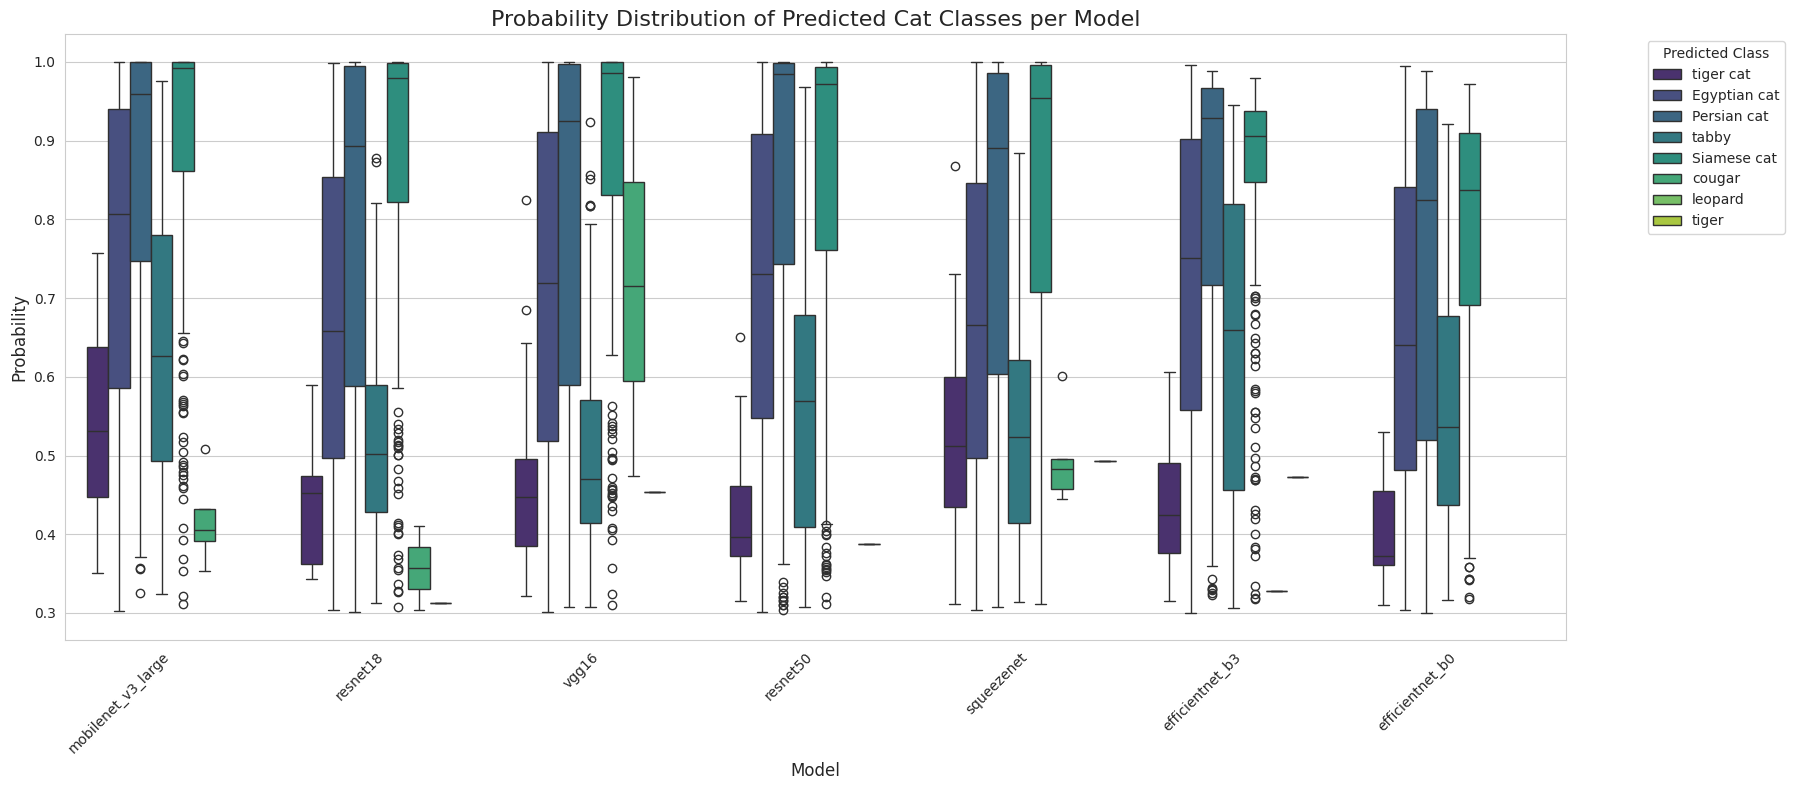

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
plt.figure(figsize=(18, 8))

# Create a box plot to visualize probability distributions per model and predicted class
sns.boxplot(data=long_df, x='model', y='probability', hue='predicted_class', palette='viridis')

# Add title and labels for better readability
plt.title('Probability Distribution of Predicted Cat Classes per Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()


In [ ]:
import os
import pandas as pd

# Define the output directory
output_directory = os.path.join('/content/drive/MyDrive/XAI_Project/results', 'combined_predictions')
os.makedirs(output_directory, exist_ok=True) # Ensure the directory exists

# Define the output filename for aggregated statistics
output_filename = 'aggregated_probability_statistics.csv'
output_path = os.path.join(output_directory, output_filename)

# Save the aggregated statistics DataFrame to a CSV file
aggregated_stats_df.to_csv(output_path, index=False)

print(f"Aggregated probability statistics saved to: {output_path}")

Aggregated probability statistics saved to: /content/drive/MyDrive/XAI_Project/results/combined_predictions/aggregated_probability_statistics.csv
